In [7]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt


Student 1: [Nina Gumbs], [6552544]
Student 2: [Luuk van Dijk], [651702]
Student 3: [Jens Groen], [6353991]

In [8]:
#Constanten
mu0 = 4*np.pi*10**-7

Dipool benadering Magneetveld circulaire halbach array

flux_kwadraat boven, Parallel, magneten: 9.544766953093437e-06 Wb
flux_kwadraat boven, Parallel, magneten: 9.544766953093437e-06 Wb
flux_kwadraat boven, Halbach, magneten: 4.5200546961182154e-06 Wb
flux_kwadraat onder, Halbach, magneten: 1.2536701337747777e-05 Wb


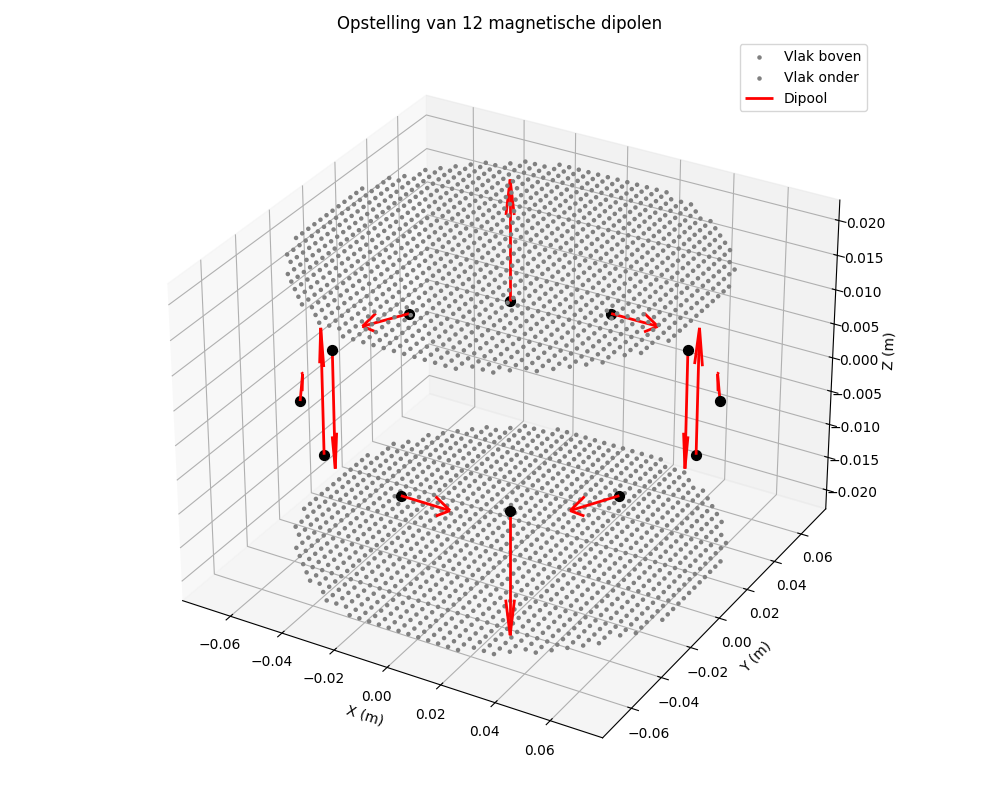

In [9]:
#########inputs#########

# aantal magneten
N = 12



#Magneet waardes
rmag = 18*10**-3
Amag = np.pi *rmag**2
hmag =  3*10**-3
Br = 1.265 # N35 ~ N45 
p = 3 #draaingrichting en snelheid van hoek van de magneten


# radius
r    = N*rmag/np.pi

#Configuratie van de magneten
configuratie_namen = {
    0: "Halbach",
    1: "Parallel",
    2: "Radiaal",
    3: "Chat Halbach"
}

configuratie = 0 
################flux_kwadraat################

#flux_kwadraatvlak 1
xo1 = 0
yo1 = 0
n1 = 40  # grid resolution
width1 = r*2.1
z_plane1 = 0.02

#flux_kwadraatvlak 2 gespiegeld op het x-y vlak
xo2 = xo1
yo2 = yo1
n2 = n1  # grid resolution
width2 = width1
z_plane2 = -z_plane1




##############Berekeningen##########


conf = configuratie_namen[configuratie]
def m(theta,conf,p):
    V = Amag * hmag
    m = (Br * V)/mu0*Magnetenrichting(theta,conf,p)
    return m

def Magnetenrichting(theta,conf,p):
    alpha = p * theta
    z_hat = np.array([0, 0, 1]) 
    r_hat = np.array([np.cos(theta), np.sin(theta), 0])
    nu_hat = np.array([-np.sin(theta), np.cos(theta), 0])

    if conf == "Halbach":
        phi = np.sin(alpha) * nu_hat + np.cos(alpha) * z_hat 
    if conf == "Parallel":
        phi = z_hat
    if conf == "Radiaal":
        phi = r_hat
    if conf == "Chat Halbach":
        phi = np.sin(alpha) * r_hat + np.cos(alpha) * z_hat
    return phi

def Magnetenpositie(r,theta):
    z = 0
    rdak = np.array([r*np.cos(theta),r*np.sin(theta),z])
    return rdak

def Bveld(r,rpunt,conf,p,N):
    Btot = np.zeros(3)
    for i in range(N):
        theta = 2*np.pi*i/N
        mag = m(theta,conf,p)
        R = rpunt - Magnetenpositie(r,theta) #vector van magneet naar meetpunt
        Rdakje = R/np.linalg.norm(R)
        B = mu0/(4*np.pi*np.linalg.norm(R)**3)*(3*np.dot(mag, Rdakje)*Rdakje - mag) 
        Btot = B + Btot
    return Btot

def maak_vlak_cirkel(width, z_plane, n=40, x_offset=0, y_offset=0):
    r_max = width / 2
    x = np.linspace(-r_max + x_offset, r_max + x_offset, n)
    y = np.linspace(-r_max + y_offset, r_max + y_offset, n)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    
    punten = []
    for xi in x:
        for yi in y:
            # Alleen punten binnen de cirkel
            if (xi - x_offset)**2 + (yi - y_offset)**2 <= r_max**2:
                rpunt = np.array([xi, yi, z_plane])
                punten.append((rpunt, dx, dy))
    
    return punten, x, y


def flux_kwadraat(meetpunten, conf, p, N):
    """Integreert Bz² over het vlak — correct voor liftkracht"""
    total = 0
    for rpunt, dx, dy in meetpunten:
        B = Bveld(r, rpunt, conf, p, N)
        total += B[2]**2 * dx * dy
    return total

# Vlak boven de magneten
vlak_boven,  x1, y1 = maak_vlak_cirkel(width1, z_plane1,n1, xo1,yo1)
vlak_onder,  x2, y2 = maak_vlak_cirkel(width2, z_plane2,n2, xo2, yo2)

print("flux_kwadraat boven, Parallel, magneten:", flux_kwadraat(vlak_boven,"Parallel", p,N), "Wb")
print("flux_kwadraat boven, Parallel, magneten:", flux_kwadraat(vlak_onder,"Parallel", p,N), "Wb")
print("flux_kwadraat boven, "+ conf +", magneten:", flux_kwadraat(vlak_boven,conf, p,N), "Wb")
print("flux_kwadraat onder, " + conf +  ", magneten:", flux_kwadraat(vlak_onder,conf,p,N), "Wb")




#######plotting########

def plot_vlak(ax, punten, color='cyan', alpha=1, label=''):
    """Plot de gridpunten van maak_vlak_cirkel als stippen in 3D."""
    xs = [p[0][0] for p in punten]
    ys = [p[0][1] for p in punten]
    zs = [p[0][2] for p in punten]
    ax.scatter(xs, ys, zs, color=color, alpha=alpha, s=5, label=label)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

#Vlak
plot_vlak(ax, vlak_boven, color='grey',   label='Vlak boven')
plot_vlak(ax, vlak_onder, color='gray', label='Vlak onder')



#magneten
for i in range(N):
    theta    = 2 * np.pi * i / N
    pos      = Magnetenpositie(r, theta)
    richting = Magnetenrichting(theta, conf, p)

    # Pijl
    ax.quiver(*pos, *richting, length=rmag, color='red',
              linewidth=2, label='Dipool' if i == 0 else "")

    ax.scatter(*pos, color='black', s=50, zorder=5)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title(f'Opstelling van {N} magnetische dipolen')
ax.legend()
plt.tight_layout()
plt.show()


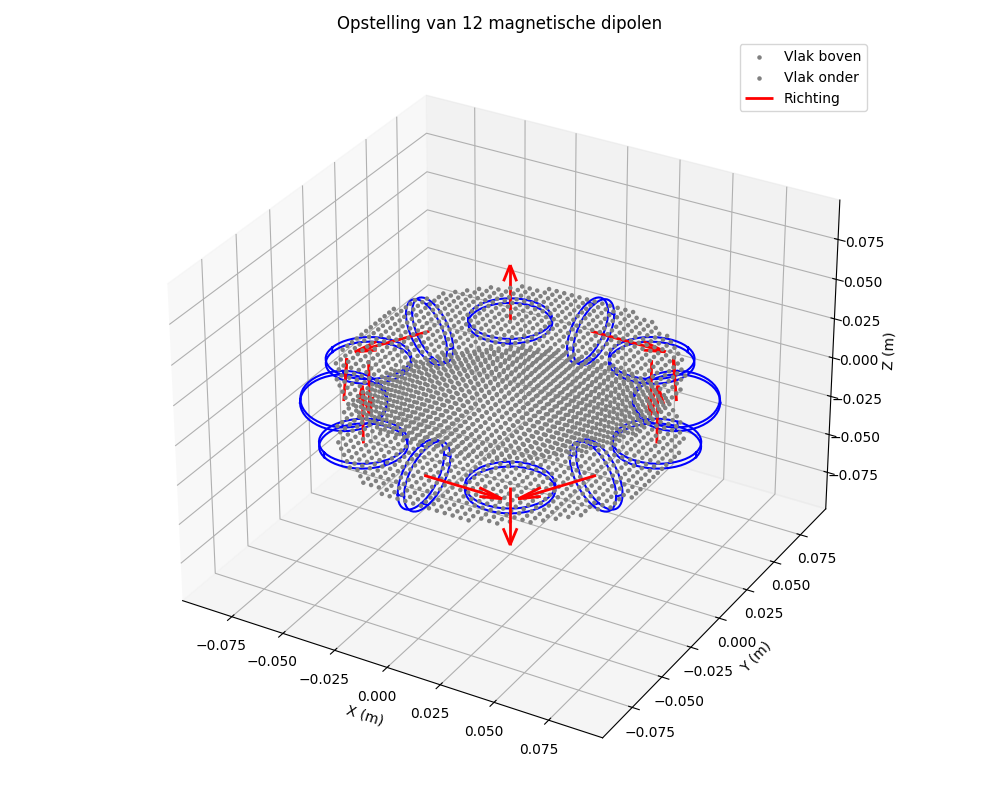

In [ ]:
#########inputs#########

# aantal magneten
N = 12



#Magneet waardes
rmag = 18*10**-3
hmag = 3*10**-3
nmag = 10

Br = 1.265 # N35 ~ N45 
p = 3 #draaingrichting en snelheid van hoek van de magneten


# radius
r = N*rmag/np.pi

#Configuratie van de magneten
configuratie_namen = {
    0: "Halbach",
    1: "Parallel",
    2: "Radiaal",
    3: "Chat Halbach"
}

configuratie = 0 
################flux_kwadraat################

#flux_kwadraatvlak 1
xo1 = 0
yo1 = 0
n1 = 40  # grid resolution
width1 = r*2.1
z_plane1 = 0.02

#flux_kwadraatvlak 2 gespiegeld op het x-y vlak
xo2 = xo1
yo2 = yo1
n2 = n1  # grid resolution
width2 = width1
z_plane2 = -z_plane1




##############Berekeningen##########

Amag = np.pi * rmag**2   # oppervlakte van de cirkelvormige magneet
conf = configuratie_namen[configuratie]
zmag = hmag/2


def m(theta, conf, p, n_punten):
    V_totaal = Amag * zmag * 2
    V_per_punt = V_totaal / n_punten      # ← verdeel volume
    m = (Br * V_per_punt) / mu0 * Magnetenrichting(theta, conf, p)
    return m

def Magnetenrichting(theta,conf,p):
    alpha = p * theta
    z_hat = np.array([0, 0, 1]) 
    r_hat = np.array([np.cos(theta), np.sin(theta), 0])
    nu_hat = np.array([-np.sin(theta), np.cos(theta), 0])

    if conf == "Halbach":
        phi = np.sin(alpha) * nu_hat + np.cos(alpha) * z_hat 
    if conf == "Parallel":
        phi = z_hat
    return phi

def centrumpositie(r,theta):
    z = 0
    rdak = np.array([r*np.cos(theta),r*np.sin(theta),z])
    return rdak


def Magnetenpositiecirkel(r, rmag, theta, zmag, nmag):
    dipoolposities = []

    z_hat  = np.array([0, 0, 1])
    r_hat  = np.array([np.cos(theta), np.sin(theta), 0])
    nu_hat = np.array([-np.sin(theta), np.cos(theta), 0])

    centrum = centrumpositie(r, theta)
    phihat = Magnetenrichting(theta, conf, p)


    if conf == "Halbach":
        t_hat = r_hat                        # radiaal — nooit parallel aan phihat
        s_hat = np.cross(phihat, t_hat)
        s_hat = s_hat / np.linalg.norm(s_hat)
    if conf == "Parallel":
        s_hat   = r_hat
        t_hat   = nu_hat


    # Twee cirkels, boven en onder
    cirkel_boven, _, _ = maak_vlak_cirkel(rmag*2, +zmag, nmag)
    cirkel_onder, _, _ = maak_vlak_cirkel(rmag*2, -zmag, nmag)

    for cirkel in [cirkel_boven, cirkel_onder]:
        for (lokaal, dx, dy) in cirkel:
            ti = lokaal[0]
            si = lokaal[1]
            punt = centrum + ti * t_hat + si * s_hat + lokaal[2] * phihat
            dipoolposities.append((punt, dx, dy))

    return dipoolposities


    


def Bveld(r, rpunt, conf, p, N, rmag, zmag, nmag):
    Btot = np.zeros(3)
    for i in range(N):
        theta = 2 * np.pi * i / N
        posities = Magnetenpositiecirkel(r, rmag, theta, zmag, nmag)
        n_punten = len(posities)                  
        mag = m(theta, conf, p, n_punten)
        
        for (magpunt, dt, ds) in posities:
            R = rpunt - magpunt
            norm_R = np.linalg.norm(R)
            if norm_R < 1e-10:
                continue
            Rdak = R / norm_R
            B = mu0 / (4 * np.pi * norm_R**3) * (3 * np.dot(mag, Rdak) * Rdak - mag)
            Btot += B
    return Btot

def maak_vlak_cirkel(width, z_plane, n=40, x_offset=0, y_offset=0):
    r_max = width / 2
    x = np.linspace(-r_max + x_offset, r_max + x_offset, n)
    y = np.linspace(-r_max + y_offset, r_max + y_offset, n)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    
    punten = []
    for xi in x:
        for yi in y:
            # Alleen punten binnen de cirkel
            if (xi - x_offset)**2 + (yi - y_offset)**2 <= r_max**2:
                rpunt = np.array([xi, yi, z_plane])
                punten.append((rpunt, dx, dy))
    
    return punten, x, y


def flux_kwadraat(meetpunten, conf, p, N,rmag,zmag,nmag):
    """Integreert Bz² over het vlak — correct voor liftkracht"""
    total = 0
    for rpunt, dx, dy in meetpunten:
        B = Bveld(r,rpunt,conf,p,N,rmag,zmag,nmag)
        total += B[2]**2 * dx * dy
    return total

# Vlak boven de magneten
vlak_boven,  x1, y1 = maak_vlak_cirkel(width1, z_plane1,n1, xo1,yo1)
vlak_onder,  x2, y2 = maak_vlak_cirkel(width2, z_plane2,n2, xo2, yo2)

# print("flux_kwadraat boven, Parallel, magneten:", flux_kwadraat(vlak_boven,"Parallel", p,N,rmag,zmag,nmag), "Wb")
# print("flux_kwadraat boven, Parallel, magneten:", flux_kwadraat(vlak_onder,"Parallel", p,N,rmag,zmag,nmag), "Wb")
# print("flux_kwadraat boven, "+ conf +", magneten:", flux_kwadraat(vlak_boven,conf, p,N,rmag,zmag,nmag), "Wb")
# print("flux_kwadraat onder, " + conf +  ", magneten:", flux_kwadraat(vlak_onder,conf,p,N,rmag,zmag,nmag), "Wb")




#######plotting########

def plot_vlak(ax, punten, color='cyan', alpha=1, label=''):
    """Plot de gridpunten van maak_vlak_cirkel als stippen in 3D."""
    xs = [p[0][0] for p in punten]
    ys = [p[0][1] for p in punten]
    zs = [p[0][2] for p in punten]
    ax.scatter(xs, ys, zs, color=color, alpha=alpha, s=5, label=label)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

#Vlak
plot_vlak(ax, vlak_boven, color='grey',   label='Vlak boven')
plot_vlak(ax, vlak_onder, color='gray', label='Vlak onder')



def plot_magneet_cilinder(ax, centrum, phihat, t_hat, s_hat, rmag, zmag, color='blue'):
    hoeken = np.linspace(0, 2*np.pi, 50)
    
    cirkel_boven = np.array([
        centrum + rmag*np.cos(a)*t_hat + rmag*np.sin(a)*s_hat + zmag*phihat 
        for a in hoeken
    ])
    cirkel_onder = np.array([
        centrum + rmag*np.cos(a)*t_hat + rmag*np.sin(a)*s_hat - zmag*phihat 
        for a in hoeken
    ])
    
    ax.plot(cirkel_boven[:,0], cirkel_boven[:,1], cirkel_boven[:,2], color=color)
    ax.plot(cirkel_onder[:,0], cirkel_onder[:,1], cirkel_onder[:,2], color=color)
    
    for a in [0, np.pi/2, np.pi, 3*np.pi/2]:
        boven = centrum + rmag*np.cos(a)*t_hat + rmag*np.sin(a)*s_hat + zmag*phihat
        onder = centrum + rmag*np.cos(a)*t_hat + rmag*np.sin(a)*s_hat - zmag*phihat
        ax.plot([boven[0],onder[0]], [boven[1],onder[1]], [boven[2],onder[2]], color=color)


for i in range(N):
    theta   = 2 * np.pi * i / N
    centrum = centrumpositie(r, theta)
    phihat  = Magnetenrichting(theta, conf, p)
    r_hat  = np.array([np.cos(theta), np.sin(theta), 0])
    if conf == "Halbach":
        t_hat = r_hat                        # radiaal — nooit parallel aan phihat
        s_hat = np.cross(phihat, t_hat)
        s_hat = s_hat / np.linalg.norm(s_hat)

    plot_magneet_cilinder(ax, centrum, phihat, t_hat, s_hat, rmag, zmag)
    ax.quiver(*centrum, *phihat, length=rmag*2, color='red',
              linewidth=2, label='Richting' if i == 0 else "")
    


def set_axes_gelijk(ax):
    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d(),
    ])
    midden = np.mean(limits, axis=1)
    bereik = np.max(limits[:, 1] - limits[:, 0]) / 2

    ax.set_xlim3d(midden[0] - bereik, midden[0] + bereik)
    ax.set_ylim3d(midden[1] - bereik, midden[1] + bereik)
    ax.set_zlim3d(midden[2] - bereik, midden[2] + bereik)



set_axes_gelijk(ax)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title(f'Opstelling van {N} magnetische dipolen')
ax.legend()
plt.tight_layout()
plt.show()


In [25]:
# Print de phihat per magneet
for i in range(N):
    theta = 2 * np.pi * i / N
    print(f"magneet {i}: phihat = {Magnetenrichting(theta, conf, p).round(2)}")

magneet 0: phihat = [0. 0. 1.]
magneet 1: phihat = [ 0.75  0.43 -0.5 ]
magneet 2: phihat = [ 0.75 -0.43 -0.5 ]


## Eddy-Current Lift Force — Afleiding

### 1. flux_kwadraat door de plaat
$$\Phi(A) = \iint_{A} B_z \, dA$$

### 2. Wet van Faraday
$$\mathcal{E} = \Phi(A) \cdot \omega$$

### 3. Weerstand van de plaat
$$R = \frac{1}{\sigma} \cdot \frac{t}{A}$$

### 4. Geïnduceerde stroom
$$I = \frac{\mathcal{E}}{R} = \frac{\sigma \cdot A \cdot \Phi(A) \cdot \omega}{t}$$

### 5. Liftkracht (Lorentz)
$$F_{lift} = I \cdot \Phi(A) = \frac{\sigma \cdot A}{t} \cdot \Phi(A)^2 \cdot \omega^2$$

### 6. Zwaartekracht
$$F_z = \rho \cdot A \cdot t \leq g$$

### 7. Levitatieconditie
$$F_{lift} > F_z$$

$$\frac{\sigma \cdot A}{t} \cdot \Phi(A)^2 \cdot \omega^2 > \rho \cdot A \cdot t \cdot g$$

### 8. Kritische hoeksnelheid
$$\boxed{\omega_{min} = \sqrt{\frac{\rho \cdot t^2 \cdot g}{\sigma \cdot \Phi(A)^2}}}$$

## $\omega_{min}$ hangt af van $\Phi(A)$ — kleine platen vangen minder flux_kwadraat op,
## dus hebben hogere $\omega$ nodig. Grote platen (groter dan het magneetpatroon) verzadigen in flux_kwadraat.

KeyboardInterrupt: 

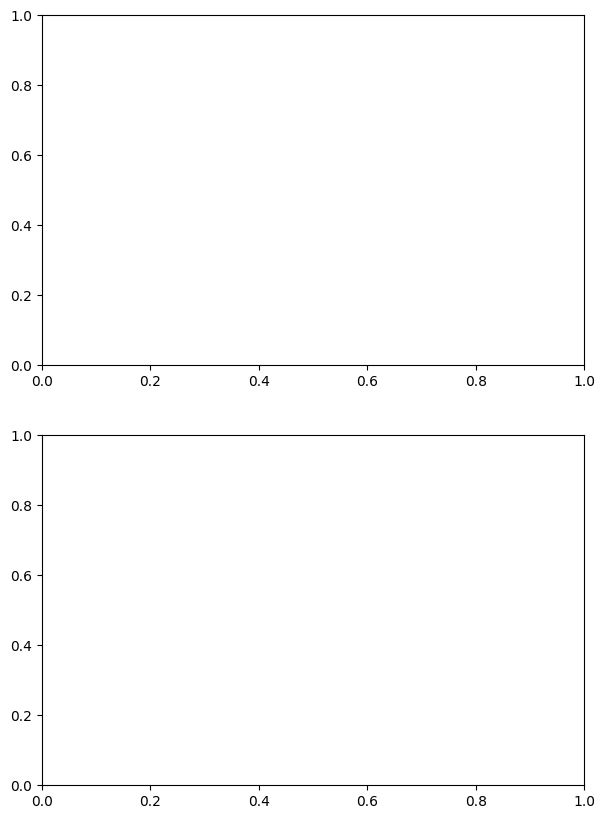

In [ ]:
# ── Constanten ───────────────────────────────────────────────
config = 1
sigma = 6e7
rho_m = 8960
g     = 9.81
t     = 0.003

# ── Parameters ───────────────────────────────────────────────
N_vals     = 12
width_vals = np.linspace(0.03, 0.5, 20)
width_cm   = width_vals * 100
n_flux_kwadraat = 30
z_plaat = np.linspace(0.05, 0.1, 10)



conf = configuratie_namen[configuratie]
# ── Figure met 2 subplots ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 10))

for Z in z_plaat:
    omega_min_vals = []
    RPM_min_vals   = []
    
    for w in width_vals:
        vlak  = maak_vlak_cirkel(w, Z, n_flux_kwadraat, xo1, yo1)[0]
        Phi2  = flux_kwadraat(vlak, conf, p, N)
        A     = w**2
        Bz    = np.sqrt(Phi2 / A)
        
        if Bz > 1e-6:
            omega_min = np.sqrt((rho_m * g) / (sigma * t * Bz**2))
            RPM       = omega_min * 60 / (2 * np.pi)
        else:
            omega_min = np.nan
            RPM       = np.nan
        
        omega_min_vals.append(omega_min)
        RPM_min_vals.append(RPM)
    
    # plot beide
    ax1.plot(width_cm, omega_min_vals, label=f"Z={Z}")
    ax2.plot(width_cm, RPM_min_vals, label=f"Z={Z}")

# ── Opmaak ───────────────────────────────────────────────────
ax1.set_xlabel("Plaatbreedte [cm]")
ax1.set_ylabel("Hoeksnelheid ω [rad/s]")
ax1.legend()
ax1.grid(True)
ax1.set_ylim(0, 1000)

ax2.set_xlabel("Plaatbreedte [cm]")
ax2.set_ylabel("Hoeksnelheid RPM [rot/min]")
ax2.legend()
ax2.grid(True)
ax2.set_ylim(0, 10000)


plt.tight_layout()
plt.show()

Om te bepalen bij welke rotatiesnelheid de Halbach-array een koperen plaat kan laten
levitieren, wordt het evenwicht tussen liftkracht en zwaartekracht opgesteld:

  ω_min = sqrt( ρ_m · g / (σ · t · <Bz²>) )

Uit de grafiek volgt dat bij Z = 5 cm een minimum bereikt wordt rond w ≈ 7 cm,
met ω_min ≈ 230 rad/s ≈ 2200 RPM. Dit is haalbaar met een standaard BLDC-motor
en toont aan dat levitatie met deze opstelling demonstreerbaar is.

Bij grotere plaat (w > 10 cm) neemt ω_min weer toe: de plaat steekt buiten het
effectieve veldgebied van de array (diameter 2r = 6,8 cm), waardoor <Bz²> daalt.
Bij kleinere plaat mist een deel van de flux het plaatoppervlak.
Het optimum ligt dus rond w ≈ 2r.

Bij grotere hoogte Z neemt ω_min sterk toe door de exponentiële veldafval,
en worden de curves buiten het plotvenster (> 1000 rad/s) geclipped.